# 2D Grey–Scott Reaction–Diffusion Equation

The Grey–Scott system models two interacting chemical species $u$ and $v$:

$$u_t = \varepsilon_1\,\Delta u + b_1(1 - u) - c_1\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$
$$v_t = \varepsilon_2\,\Delta v - b_2\,v + c_2\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$

**Periodic boundary conditions** on both $x$ and $y$.

**Initial conditions:**
$$u_0(x,y) = 1 - e^{-10\left((x+0.05)^2+(y+0.02)^2\right)}$$
$$v_0(x,y) = e^{-10\left((x-0.05)^2+(y-0.02)^2\right)}$$

**Parameters:** $\varepsilon_1=0.2$, $\varepsilon_2=0.1$, $b_1=40$, $b_2=100$, $c_1=c_2=1000$.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp

## Domain

$(x,y) \in [-1,1]^2$, $t \in [0,2]$. Periodic BCs on both spatial axes.


In [2]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],  # (x_min, x_max), (y_min, y_max)
    time =np.linspace(0.0, 2.0, 11),   # 10 time partitions: [0, 0.2, 0.4, …, 2.0]
)

## PDE Residuals

Two coupled residuals, one per species. The network outputs $[u, v]$.

$$\mathcal{R}_u = u_t - \varepsilon_1(u_{xx} + u_{yy}) - b_1(1-u) + c_1 u v^2 = 0$$
$$\mathcal{R}_v = v_t - \varepsilon_2(v_{xx} + v_{yy}) + b_2 v - c_2 u v^2 = 0$$


In [3]:
import jax

problem = pinns.ProblemStrong(domain=domain, output_names=["u", "v"])

def grey_scott_residual(X, U, params, derivative=None):
    # X columns: 0=x, 1=y, 2=t
    p = params
    eps1 = p['parameter']['eps1'];  eps2 = p['parameter']['eps2']
    b1   = p['parameter']['b1'];    b2   = p['parameter']['b2']
    c1   = p['parameter']['c1'];    c2   = p['parameter']['c2']

    u = U[:, 0:1]
    v = U[:, 1:2]

    dt_all   = derivative.all(X, (2,))       # (N, 2): [u_t,  v_t ]
    dxx_all  = derivative.all(X, (0, 0))     # (N, 2): [u_xx, v_xx]
    dyy_all  = derivative.all(X, (1, 1))     # (N, 2): [u_yy, v_yy]

    u_t  = dt_all[:,  0:1];  v_t  = dt_all[:,  1:2]
    u_xx = dxx_all[:, 0:1];  v_xx = dxx_all[:, 1:2]
    u_yy = dyy_all[:, 0:1];  v_yy = dyy_all[:, 1:2]

    uv2 = u * v**2

    res_u = u_t - eps1 * (u_xx + u_yy) - b1 * (1.0 - u) + c1 * uv2
    res_v = v_t - eps2 * (v_xx + v_yy) + b2 * v          - c2 * uv2

    return jnp.concatenate([res_u, res_v], axis=1)   # (N, 2)

problem.add_inner(grey_scott_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    y = X[:, 1:2]
    u0 = 1.0 - jnp.exp(-10.0 * ((x + 0.05)**2 + (y + 0.02)**2))
    v0 =       jnp.exp(-10.0 * ((x - 0.05)**2 + (y - 0.02)**2))   
    return jnp.concatenate([u0, v0], axis=1)   # (N, 2)

problem.add_initial(u_initial, name="initial", outputs=["u", "v"])

problem.add_parameter("eps1", 0.2)

problem.add_parameter("eps2", 0.1)

problem.add_parameter("b1",   40.0)
problem.add_parameter("b2",   100.0)
problem.add_parameter("c1",   1000.0)
problem.add_parameter("c2",   1000.0)


ProblemStrong(domain=DomainCubic, n_dims=3, n_outputs=2, inner=1, boundary=0, initial=2, params=['eps1', 'eps2', 'b1', 'b2', 'c1', 'c2'], trainable=[])

### Reference Solution (pseudo-spectral ETD2RK)

Both species are evolved spectrally on a 2-D periodic grid using `ModelSolver` +
`IntegratorETD2RK` (Cox–Matthews exponential time differencing).  In Fourier space:

$$\partial_t \hat{u}_\mathbf{k} = \underbrace{-\varepsilon_1 |\mathbf{k}|^2 \hat{u}_\mathbf{k}}_{\text{linear (exact)}} + \underbrace{\widehat{b_1(1-u) - c_1 u v^2}}_{\text{nonlinear}}$$

`IntegratorETD2RK` treats the stiff diffusion exactly via matrix exponentials
(pointwise in Fourier space), avoiding the small-step restriction of explicit methods.


U_ref shape: (201, 128, 128)  range [0.0003, 1.0000]
V_ref shape: (201, 128, 128)  range [-0.0015, 0.9997]


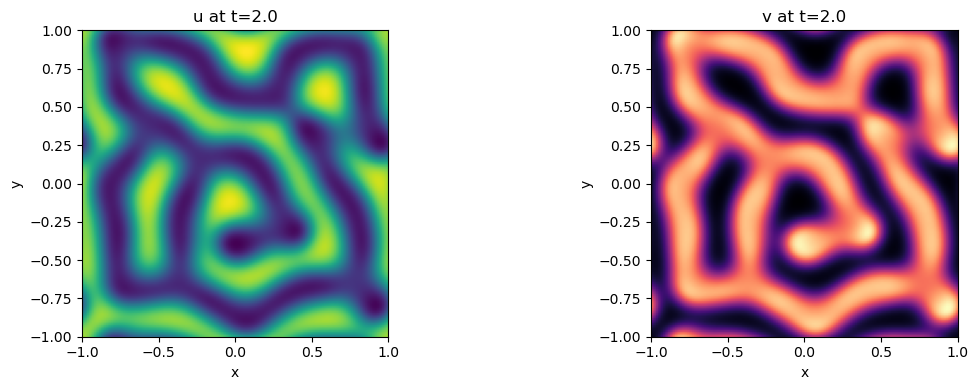

In [4]:
from scipy.interpolate import RegularGridInterpolator

# ── Parameters ────────────────────────────────────────────────────────────────
eps1_val = 0.2;    eps2_val = 0.1
b1_val   = 40.0;   b2_val   = 100.0
c1_val   = 1000.0; c2_val   = 1000.0

Nx = Ny = 128
Nt = 201        # saved snapshots (includes t=0)
T  = 2.0

t_ref = np.linspace(0.0, T, Nt)

# ── DomainCubic (geometry / sampling) ─────────────────────────────────────────
domain_gs = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],
    time=(0.0, T),
)

# ── ModelSpectralSolver (2D periodic Fourier basis, shape=(Nx,Ny)) ───────────────────
#   Linear part:  L_u = -eps1*K², L_v = -eps2*K²  (exact in Fourier space)
#   Nonlinear:    N_u = b1*(1-u) - c1*u*v²,  N_v = -b2*v + c2*u*v²

integrator_gs = pinns.IntegratorETD2RK(dt=1e-4, checkpoint=False)

model_gs = pinns.ModelSpectralSolver(domain_gs, ["u", "v"], integrator_gs, shape=(Nx, Ny))

x_ref = np.array(model_gs._grids[0])   # (Nx,)
y_ref = np.array(model_gs._grids[1])   # (Ny,)

model_gs.set_linear_op(
    lambda K2, p: {
        "u": -p["eps1"] * K2,
        "v": -p["eps2"] * K2,
    }
)

def gs_nonlinear(state_hat, p):
    u   = model_gs.inverse(state_hat["u"])
    v   = model_gs.inverse(state_hat["v"])
    uv2 = u * v**2
    Nu  = p["b1"] * (1.0 - u) - p["c1"] * uv2
    Nv  = -p["b2"] * v        + p["c2"] * uv2
    return {
        "u": model_gs.forward(Nu),
        "v": model_gs.forward(Nv),
    }

model_gs.set_nonlinear_op(gs_nonlinear)
model_gs.add_parameter("eps1", eps1_val)
model_gs.add_parameter("eps2", eps2_val)
model_gs.add_parameter("b1",   b1_val)
model_gs.add_parameter("b2",   b2_val)
model_gs.add_parameter("c1",   c1_val)
model_gs.add_parameter("c2",   c2_val)

# ── Initial conditions ────────────────────────────────────────────────────────
XX, YY = np.meshgrid(x_ref, y_ref, indexing='ij')
u0 = jnp.array(1.0 - np.exp(-10.0 * ((XX + 0.05)**2 + (YY + 0.02)**2)))
v0 = jnp.array(      np.exp(-10.0 * ((XX - 0.05)**2 + (YY - 0.02)**2)))

model_gs.add_initial({"u": u0, "v": v0})

# ── Forward solve ─────────────────────────────────────────────────────────────
sol = model_gs.solve(t_obs=t_ref)
U_ref = np.array(sol["u"])   # (Nt, Nx, Ny)
V_ref = np.array(sol["v"])   # (Nt, Nx, Ny)

print(f"U_ref shape: {U_ref.shape}  range [{U_ref.min():.4f}, {U_ref.max():.4f}]")
print(f"V_ref shape: {V_ref.shape}  range [{V_ref.min():.4f}, {V_ref.max():.4f}]")

# ── Interpolants: X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2) ──────────────────────
_interp_u = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    U_ref.transpose(1, 2, 0),   # (Nx, Ny, Nt)
    method='linear', bounds_error=False, fill_value=None,
)
_interp_v = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    V_ref.transpose(1, 2, 0),
    method='linear', bounds_error=False, fill_value=None,
)

def uv_reference(X):
    """X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2)"""
    pts = np.asarray(X)[:, :3]
    return np.concatenate([
        _interp_u(pts)[:, None],
        _interp_v(pts)[:, None],
    ], axis=1)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(U_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='viridis')
axes[0].set_title(f"u at t={T}"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[1].imshow(V_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='magma')
axes[1].set_title(f"v at t={T}"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout()


## Data-Driven Fitting (no physics)

We sample **20 000 scattered points** $(x_i, y_i, t_i)$ uniformly from the
space–time domain and read off the corresponding reference values $(u_i, v_i)$,
then add 1 % Gaussian noise.  A Fourier-feature network is trained purely from
data — no PDE residual is imposed.

The network architecture is:

$$\text{Input: }(x,y,t) \xrightarrow{\text{Normalize}} \text{RFF}(256,\,\sigma=3) \rightarrow \text{FNN}[128,128,128] \xrightarrow{\tanh} (u,v)$$

Random Fourier Features (Tancik et al., 2020) with $\sigma=3$ cover the relevant
spatial frequencies of the Grey–Scott pattern ($\sim 10$ cycles per unit length).


In [5]:
# ── Sample 20 000 scattered (x, y, t) points ─────────────────────────────────
rng = np.random.default_rng(0)
N_data = 20_000

# uniform random samples over [-1,1]² × [0,T]
x_samp = rng.uniform(-1.0,  1.0, N_data).astype(np.float32)
y_samp = rng.uniform(-1.0,  1.0, N_data).astype(np.float32)
t_samp = rng.uniform( 0.0,    T, N_data).astype(np.float32)

X_data = np.stack([x_samp, y_samp, t_samp], axis=1)   # (N_data, 3)

# Interpolate reference solution at the sampled points and add 1% Gaussian noise
u_data = (_interp_u(X_data) + rng.normal(0, 0.01, N_data)).astype(np.float32)
v_data = (_interp_v(X_data) + rng.normal(0, 0.01, N_data)).astype(np.float32)
uv = np.stack([u_data, v_data], axis=1)   # (N_data, 2)

# ── Dataset — one term per species so each gets its own loss/error ────────────
dataset = pinns.Dataset()
dataset.add_points(X_data, uv, name="data", outputs=["u", "v"])
# → registers "data_u" (component 0) and "data_v" (component 1) separately

print(f"Dataset: {N_data} points  u∈[{u_data.min():.3f}, {u_data.max():.3f}]  "
      f"v∈[{v_data.min():.3f}, {v_data.max():.3f}]")


Dataset: 20000 points  u∈[0.066, 1.037]  v∈[-0.038, 0.692]


In [6]:
# ── Fourier-feature network ───────────────────────────────────────────────────
# Input: (x, y, t) — 3 dims.  Output: (u, v) — 2 dims.
# RFF with σ=3 covers ~10 cycles/unit, matching the Grey–Scott pattern scale.
net = pinns.create_model(
    domain_gs,
    output_dim=2,
    features=pinns.FourierFeatures(n_features=256, sigma=3.0),
    core=pinns.FNN([256, 256, 256], output_activation="tanh"),
    normalize=True,
)
print(net)


ModelBase(output_dim=2)
  [Normalize_0] Normalize(n_coord=3, n_context=0, context_scaled=False)
  [RandomFourierFeatures_1] RandomFourierFeatures(fourier_input_dim=3, n_features=256, sigma=3.0, adaptive=True)
  [FNN_2] FNN(layer_sizes=[512, 256, 256, 256, 2])


Starting training for 1000 epochs (JIT-compiled)...


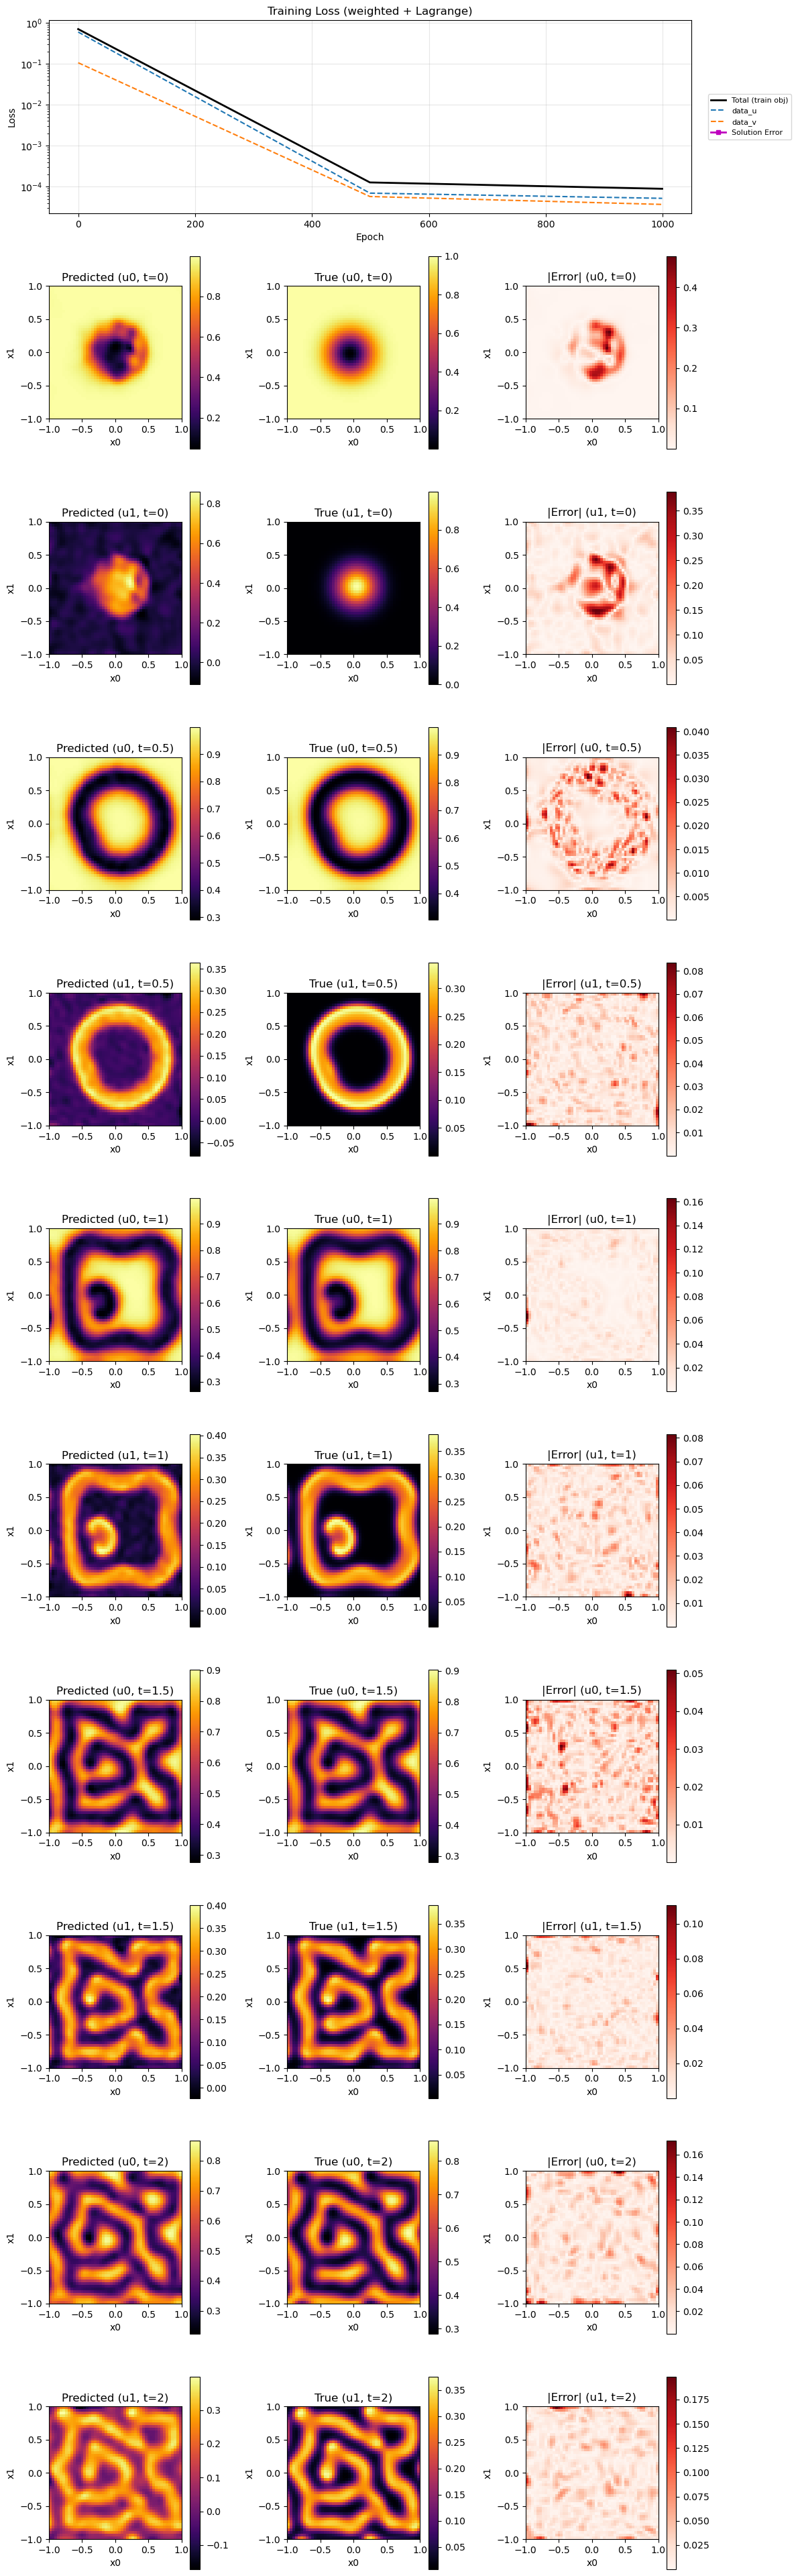

Epoch 0/1000 | Loss: 7.04e-01 | MSE: 7.04e-01 | Terms: [] | Data: [data_u: 5.98e-01, data_v: 1.06e-01] | Error: N/A | Time: 0.0s
Epoch 500/1000 | Loss: 1.27e-04 | MSE: 1.27e-04 | Terms: [] | Data: [data_u: 6.95e-05, data_v: 5.75e-05] | Error: N/A | Time: 11.2s
Epoch 1000/1000 | Loss: 8.88e-05 | MSE: 8.88e-05 | Terms: [] | Data: [data_u: 5.19e-05, data_v: 3.69e-05] | Error: N/A | Time: 16.0s
Training complete in 18.0s


In [7]:
# ── Train ─────────────────────────────────────────────────────────────────────
trainer = pinns.Trainer(net, problem=None, dataset=dataset)
trainer.add_solution(uv_reference)   # for live error tracking

trainer.compile(
    dataset={
        "data_u": {"train": 2000, "test": 100, "weight": 1.0},
        "data_v": {"train": 2000, "test": 100, "weight": 1.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1)
    ],
    epochs=1000,
    print_each=500,
    show=pinns.TrainPlotter(time_points=[0.0, 0.5, 1.0, 1.5, 2.0]),
)

trainer.train()

## PINN Fine-Tuning (warm start from data-driven weights)

The data-driven network already captures the large-scale structure of the
solution.  We now **fine-tune it with physics**, adding:

* **PDE residual** $\mathcal{R}_u, \mathcal{R}_v$ in the interior
* **Initial condition** $u_0, v_0$ on $t = 0$
* **Data** terms kept at a lower weight so the PDE takes over

The network parameters are taken directly from the just-trained `trainer`,
so no random re-initialisation is needed.


Starting training for 20000 epochs (JIT-compiled)...


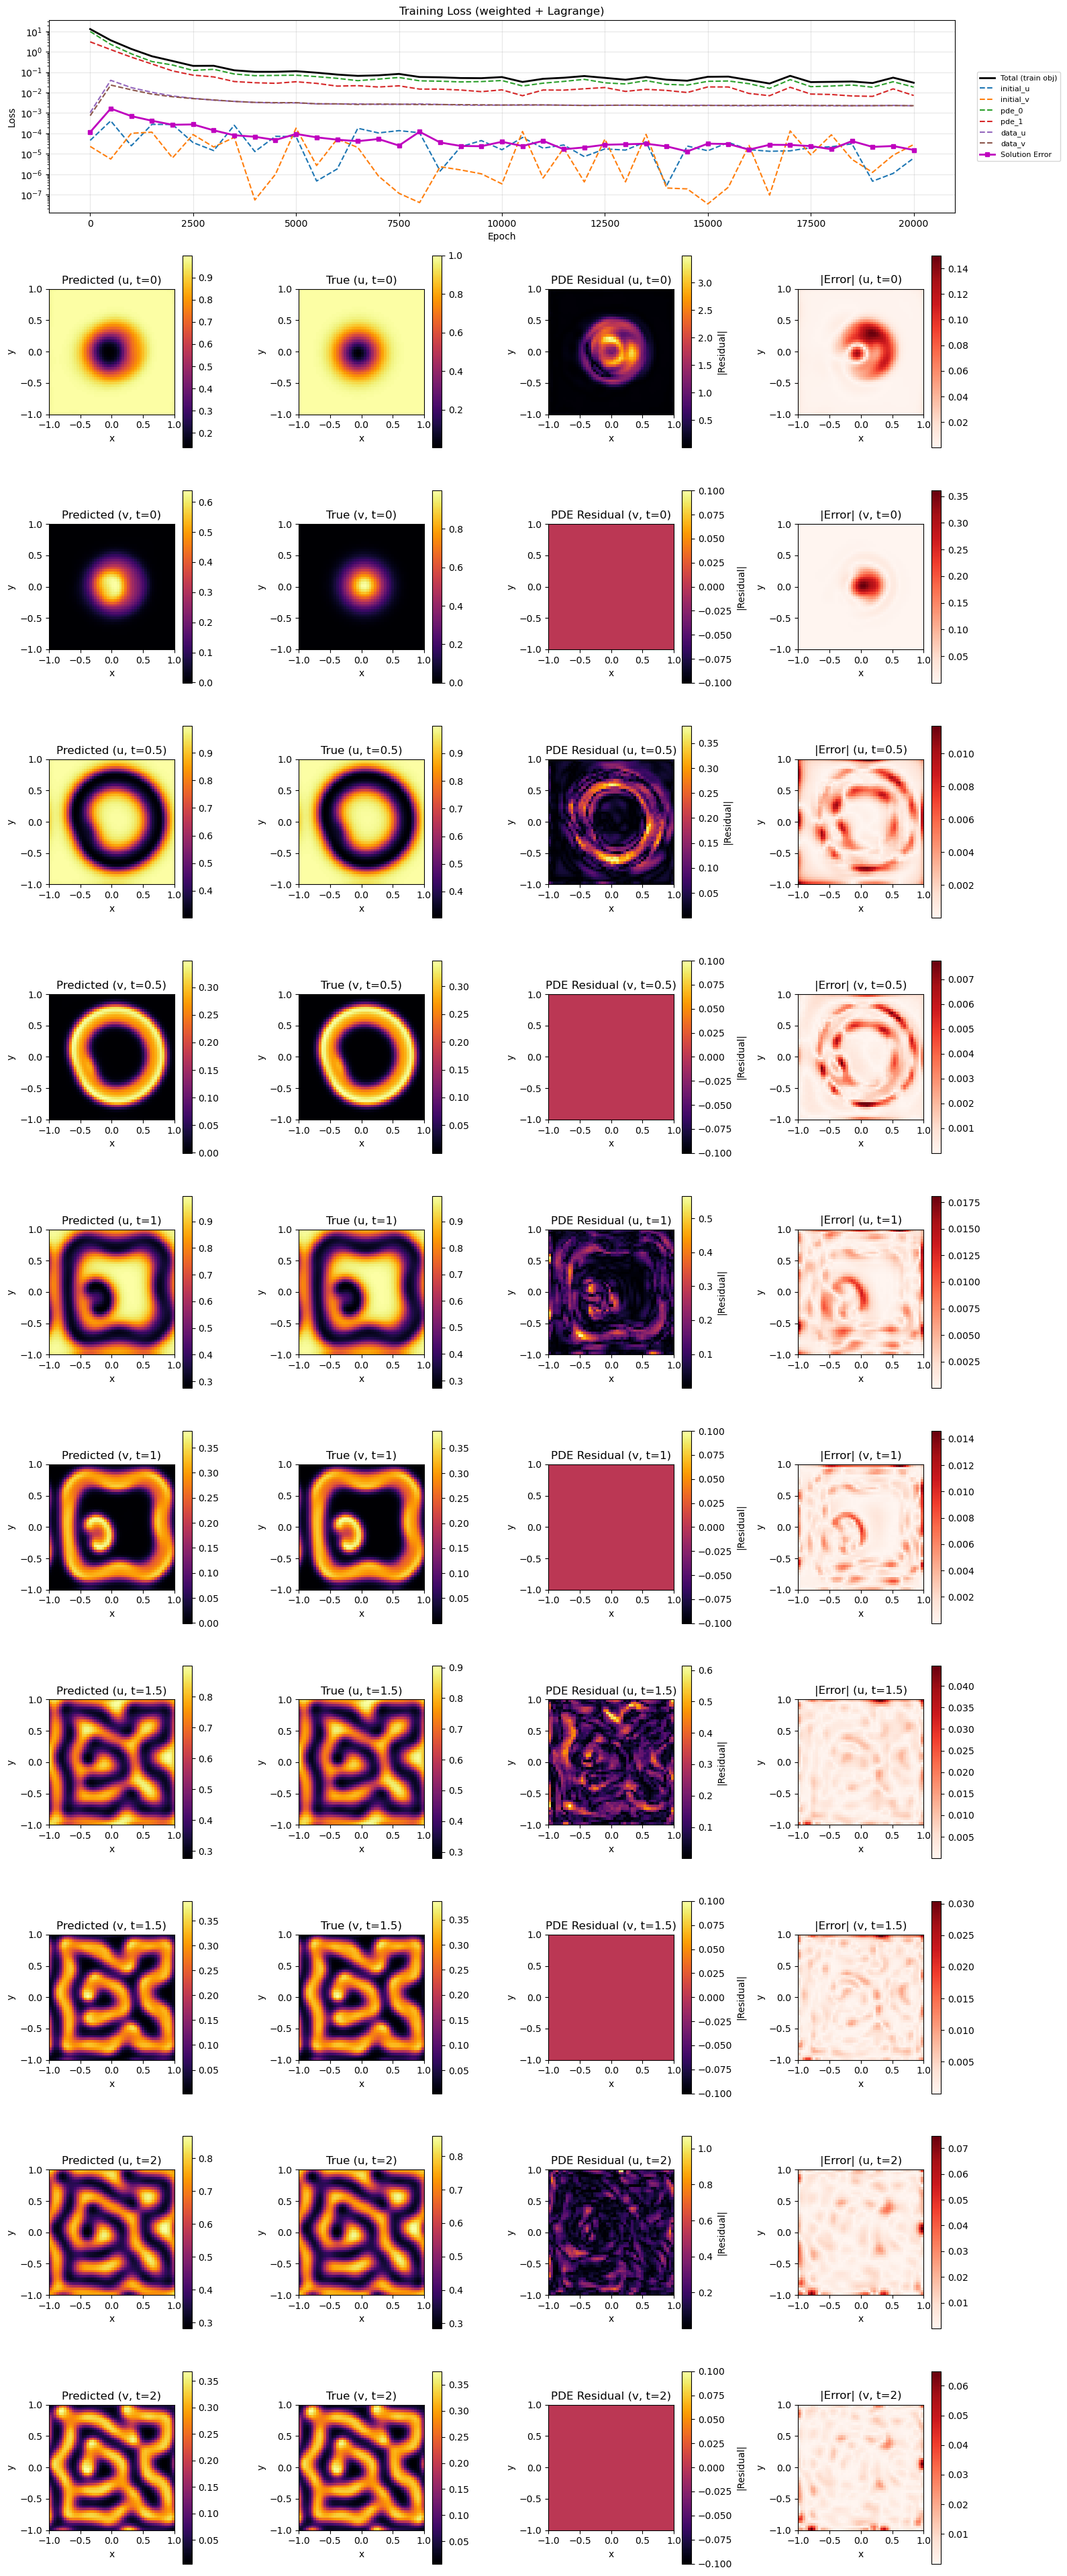

Epoch 0/20000 | Loss: 1.29e+01 | MSE: 1.29e+01 | Terms: [initial_u: 4.56e-03, initial_v: 2.30e-03, pde_0: 9.82e+00, pde_1: 3.06e+00] | Data: [data_u: 1.04e-03, data_v: 7.37e-04] | Error: 1.16e-04 | Time: 0.0s
Epoch 500/20000 | Loss: 3.64e+00 | MSE: 3.68e+00 | Terms: [initial_u: 4.10e-02, initial_v: 5.54e-04, pde_0: 2.30e+00, pde_1: 1.27e+00] | Data: [data_u: 3.99e-02, data_v: 2.33e-02] | Error: 1.64e-03 | Time: 15.0s
Epoch 1000/20000 | Loss: 1.37e+00 | MSE: 1.38e+00 | Terms: [initial_u: 2.47e-03, initial_v: 1.01e-02, pde_0: 7.93e-01, pde_1: 5.44e-01] | Data: [data_u: 1.75e-02, data_v: 1.37e-02] | Error: 7.01e-04 | Time: 21.8s
Epoch 1500/20000 | Loss: 6.03e-01 | MSE: 6.42e-01 | Terms: [initial_u: 2.78e-02, initial_v: 1.15e-02, pde_0: 3.32e-01, pde_1: 2.52e-01] | Data: [data_u: 1.03e-02, data_v: 8.43e-03] | Error: 4.18e-04 | Time: 28.6s
Epoch 2000/20000 | Loss: 3.53e-01 | MSE: 3.80e-01 | Terms: [initial_u: 2.74e-02, initial_v: 6.33e-04, pde_0: 2.24e-01, pde_1: 1.15e-01] | Data: [data_u: 

In [8]:
# ── PINN trainer (warm-started from data-fitting weights) ─────────────────────
# Trainer.__init__ resets model.params to None, so we must save the trained
# parameters first and restore them after construction.
pretrained_params = trainer.model.params   # JAX pytree from data-fitting phase

pinn_trainer = pinns.Trainer(net, problem=problem, dataset=dataset)
pinn_trainer.model.params = pretrained_params   # restore warm-start weights

pinn_trainer.add_solution(uv_reference)   # live error tracking against reference

pinn_trainer.compile(
    # PDE and IC terms
    problem={
        "initial": {"n_points": 1000, "weight": 0.01},
        "pde":     {"n_points": 4000, "weight": 0.01},
    },
    # Data terms kept at reduced weight so the PDE can take over
    dataset={
        "data_u": {"train": 2000, "test": 100, "weight": 1.0},
        "data_v": {"train": 2000, "test": 100, "weight": 1.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[pinns.SchedulerResample(1)],
    epochs=20000,
    print_each=500,
    show=pinns.TrainPlotter(time_points=[0.0, 0.5, 1.0, 1.5, 2.0]),
)

pinn_trainer.train()